## 画像マスの抽出

In [1]:
import cv2
filename = "../data/level1/sample.jpg"
img = cv2.imread(filename, cv2.IMREAD_COLOR)
if img is None:
    raise IOError("FaileRd to load image: {:s}".format(filename))

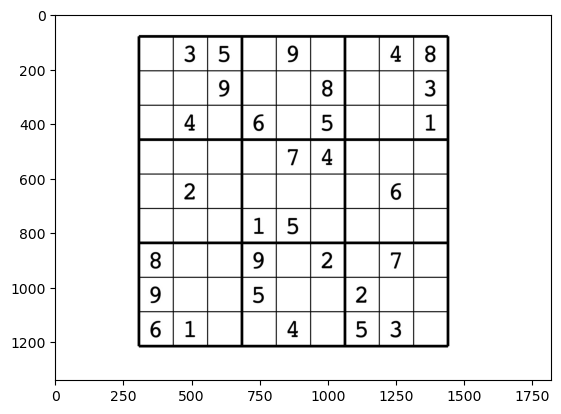

In [7]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

In [2]:
import cv2
import numpy as np

# 画像を読み込む
# img = cv2.imread('your_image.png')

# グレースケールに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 二値化
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# 輪郭を見つける
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 9x9の格子の外枠を見つける（最も大きな輪郭と想定）
largest_contour = max(contours, key=cv2.contourArea)

# マス目の輪郭の四角を描く
x, y, w, h = cv2.boundingRect(largest_contour)

# 各マス目の画像を抽出し、リストに保存
cell_images = []
stepx = w // 9
stepy = h // 9
for i in range(9):
    for j in range(9):
        cell = img[y + j*stepy:y + (j+1)*stepy, x + i*stepx:x + (i+1)*stepx]
        cell_images.append(cell)

# 例として、抽出したマス目の画像を保存
for idx, cell in enumerate(cell_images):
    cv2.imwrite(f"cell_{idx}.png", cell)


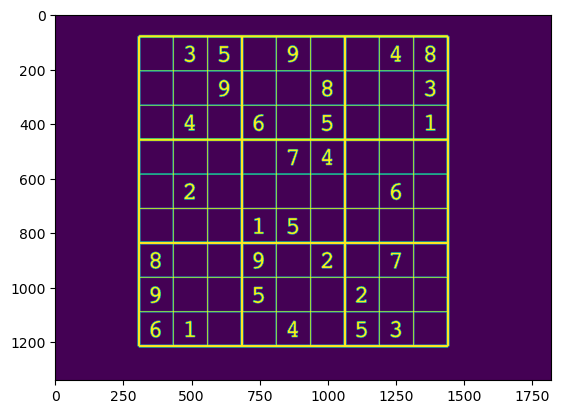

In [27]:
plt.imshow(thresh)
plt.show()

In [4]:
print(thresh)
thresh.shape

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


(1340, 1820)